In [1]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import random

print(f" PyTorch version : {torch.__version__}")

 PyTorch version : 2.6.0+cpu


In [2]:
def appliquer_clahe(image_path):
    """
    Charge une image et applique le pipeline complet :
    Gris → CLAHE → Resize 224x224 → Normalisation
    """
    # Étape 1 : Charger en niveaux de gris
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Étape 2 : CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)
    
    # Étape 3 : Resize 224x224
    img = cv2.resize(img, (224, 224))
    
    # Étape 4 : Normalisation (0-255 → 0.0-1.0)
    img = img / 255.0
    
    return img

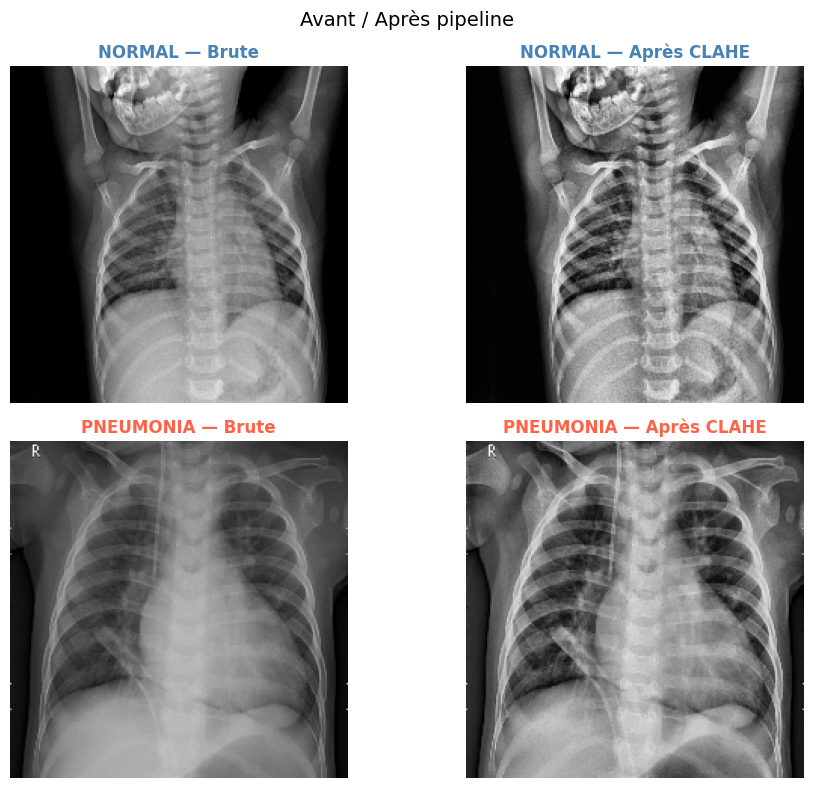

 Valeurs min/max après normalisation : 0.01 / 1.00


In [4]:
# Tester sur une image normale et une pneumonie
DATA_DIR  = "../data/chest_xray/train"

img_normal_path = os.path.join(
    DATA_DIR, "NORMAL",
    random.choice(os.listdir(os.path.join(DATA_DIR, "NORMAL")))
)
img_pneumo_path = os.path.join(
    DATA_DIR, "PNEUMONIA",
    random.choice(os.listdir(os.path.join(DATA_DIR, "PNEUMONIA")))
)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, (path, label) in enumerate([
    (img_normal_path, "NORMAL"),
    (img_pneumo_path, "PNEUMONIA")
]):
    # Avant pipeline
    brute = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    brute = cv2.resize(brute, (224, 224))
    
    # Après pipeline
    traitee = appliquer_clahe(path)
    
    couleur = "steelblue" if label == "NORMAL" else "tomato"
    
    axes[i][0].imshow(brute,   cmap="gray")
    axes[i][0].set_title(f"{label} — Brute",   color=couleur, fontweight="bold")
    axes[i][0].axis("off")
    
    axes[i][1].imshow(traitee, cmap="gray")
    axes[i][1].set_title(f"{label} — Après CLAHE", color=couleur, fontweight="bold")
    axes[i][1].axis("off")

plt.suptitle("Avant / Après pipeline", fontsize=14)
plt.tight_layout()
plt.show()

print(f" Valeurs min/max après normalisation : {traitee.min():.2f} / {traitee.max():.2f}")

In [ ]:
class PneumoniaDataset(Dataset):
    """
    Classe qui dit à PyTorch :
    - Où sont mes images
    - Comment les charger
    - Quelle est leur étiquette (0=NORMAL, 1=PNEUMONIA)
    """
    
    def __init__(self, data_dir, transform=None):
        self.data_dir  = data_dir
        self.transform = transform
        self.images    = []  # liste des chemins
        self.labels    = []  # liste des étiquettes
        
        # Parcourir NORMAL (label=0) et PNEUMONIA (label=1)
        for label, classe in enumerate(["NORMAL", "PNEUMONIA"]):
            dossier = os.path.join(data_dir, classe)
            for fichier in os.listdir(dossier):
                if fichier.endswith((".jpg", ".jpeg", ".png")):
                    self.images.append(os.path.join(dossier, fichier))
                    self.labels.append(label)
        
        print(f" Dataset chargé : {len(self.images)} images")
        print(f"   NORMAL    : {self.labels.count(0)}")
        print(f"   PNEUMONIA : {self.labels.count(1)}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Charger et traiter l'image
        img   = appliquer_clahe(self.images[idx])
        label = self.labels[idx]
        
        # Convertir en tensor PyTorch (C, H, W)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        
        # Répéter le canal gris 3 fois → RGB simulé (pour ResNet)
        img = img.repeat(3, 1, 1)
        
        return img, torch.tensor(label, dtype=torch.long)

In [7]:
TRAIN_DIR = "../data/chest_xray/train"
VAL_DIR   = "../data/chest_xray/val"
TEST_DIR  = "../data/chest_xray/test"

# Instancier les datasets
train_dataset = PneumoniaDataset(TRAIN_DIR)
val_dataset   = PneumoniaDataset(VAL_DIR)
test_dataset  = PneumoniaDataset(TEST_DIR)

# DataLoaders : chargent les images par batch
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Vérification
batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n Un batch contient :")
print(f"   Images shape : {batch_imgs.shape}")   # [32, 3, 224, 224]
print(f"   Labels shape : {batch_labels.shape}") # [32]


✅ Dataset chargé : 5216 images
   NORMAL    : 1341
   PNEUMONIA : 3875
✅ Dataset chargé : 16 images
   NORMAL    : 8
   PNEUMONIA : 8
✅ Dataset chargé : 624 images
   NORMAL    : 234
   PNEUMONIA : 390

 Un batch contient :
   Images shape : torch.Size([32, 3, 224, 224])
   Labels shape : torch.Size([32])


In [8]:
from torch.utils.data import WeightedRandomSampler

# Calculer le poids de chaque classe
# Plus la classe est rare → plus son poids est élevé
nb_normal    = 1341
nb_pneumonie = 3875
total        = nb_normal + nb_pneumonie

poids_classes = [
    total / nb_normal,     # NORMAL    → poids élevé 
    total / nb_pneumonie   # PNEUMONIA → poids faible 
]

print(f"Poids NORMAL    : {poids_classes[0]:.2f}")
print(f"Poids PNEUMONIA : {poids_classes[1]:.2f}")

# Assigner le poids à chaque image du dataset
poids_images = [poids_classes[label] for label in train_dataset.labels]

# Créer le sampler
sampler = WeightedRandomSampler(
    weights     = poids_images,
    num_samples = len(poids_images),
    replacement = True
)

# Nouveau DataLoader avec le sampler
train_loader_balanced = DataLoader(
    train_dataset,
    batch_size = 32,
    sampler    = sampler   # remplace shuffle=True
)

print("\n DataLoader équilibré créé !")

Poids NORMAL    : 3.89
Poids PNEUMONIA : 1.35

 DataLoader équilibré créé !


In [9]:
# Compter la distribution dans quelques batchs
from collections import Counter

compteur = Counter()
for i, (imgs, labels) in enumerate(train_loader_balanced):
    compteur.update(labels.numpy().tolist())
    if i == 9:  # 10 batchs
        break

print(f"Sur 10 batchs :")
print(f"NORMAL    : {compteur[0]}")
print(f"PNEUMONIA : {compteur[1]}")

Sur 10 batchs :
NORMAL    : 171
PNEUMONIA : 149


✅ Dataset chargé : 5216 images
   NORMAL    : 1341
   PNEUMONIA : 3875
   Augmentation : ✅ activée
✅ Dataset chargé : 16 images
   NORMAL    : 8
   PNEUMONIA : 8
   Augmentation : ❌ désactivée
✅ Dataset chargé : 624 images
   NORMAL    : 234
   PNEUMONIA : 390
   Augmentation : ❌ désactivée
✅ Dataset chargé : 5216 images
   NORMAL    : 1341
   PNEUMONIA : 3875
   Augmentation : ✅ activée


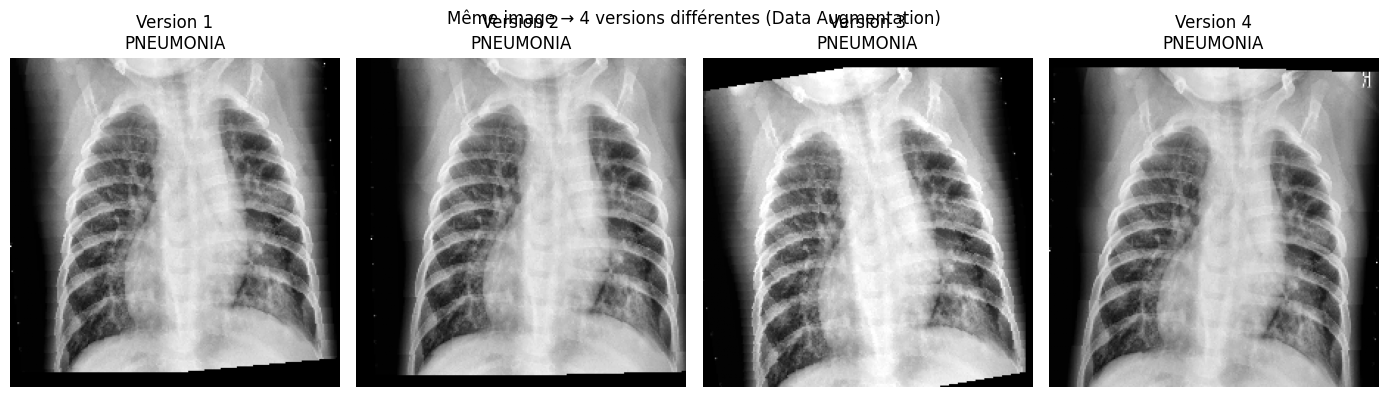

In [11]:
import sys
sys.path.append("..")

from src.dataset import get_dataloaders
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "../data/chest_xray"

train_loader, val_loader, test_loader = get_dataloaders(DATA_DIR)

# Visualiser l'effet de l'augmentation
# Charger la même image 4 fois → elle doit être différente à chaque fois
from src.dataset import PneumoniaDataset
import os, random

dataset_train = PneumoniaDataset(os.path.join(DATA_DIR, "train"), train=True)

# Prendre la même image et l'afficher 4 fois
idx = random.randint(0, len(dataset_train)-1)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(4):
    img, label = dataset_train[idx]
    img_np = img.permute(1, 2, 0).numpy()[:, :, 0]
    axes[i].imshow(img_np, cmap="gray")
    axes[i].set_title(f"Version {i+1}\n{'NORMAL' if label==0 else 'PNEUMONIA'}")
    axes[i].axis("off")

plt.suptitle("Même image → 4 versions différentes (Data Augmentation)", fontsize=12)
plt.tight_layout()
plt.show()